# ACER Data Science Machine Learning Task

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

### Loading the Data

In [2]:
student_performance = pd.read_csv("student_performance_dataset.csv")

In [3]:
student_performance.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
student_data = pd.read_csv("student_data.csv")

In [5]:
student_data.head()

,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


Student Data Labels

| Column | Variable Name | Description / Encoding |
|---|---|---|
| STUDENT ID | Student ID | Unique identifier for each student |
| 1 | Student Age | 1: 18–21, 2: 22–25, 3: above 26 |
| 2 | Sex | 1: female, 2: male |
| 3 | Graduated high-school type | 1: private, 2: state, 3: other |
| 4 | Scholarship type | 1: None, 2: 25%, 3: 50%, 4: 75%, 5: Full |
| 5 | Additional work | 1: Yes, 2: No |
| 6 | Regular artistic or sports activity | 1: Yes, 2: No |
| 7 | Has a partner | 1: Yes, 2: No |
| 8 | Total salary (if available) | 1: USD 135–200, 2: USD 201–270, 3: USD 271–340, 4: USD 341–410, 5: above 410 |
| 9 | Transportation to university | 1: Bus, 2: Private car/taxi, 3: Bicycle, 4: Other |
| 10 | Accommodation type | 1: Rental, 2: Dormitory, 3: With family, 4: Other |
| 11 | Mother's education | 1: Primary, 2: Secondary, 3: High school, 4: University, 5: MSc, 6: PhD |
| 12 | Father's education | 1: Primary, 2: Secondary, 3: High school, 4: University, 5: MSc, 6: PhD |
| 13 | Number of siblings | 1: 1, 2: 2, 3: 3, 4: 4, 5: 5 or above |
| 14 | Parental status | 1: Married, 2: Divorced, 3: Died (one or both) |
| 15 | Mother's occupation | 1: Retired, 2: Housewife, 3: Government officer, 4: Private sector, 5: Self-employed, 6: Other |
| 16 | Father's occupation | 1: Retired, 2: Government officer, 3: Private sector, 4: Self-employed, 5: Other |
| 17 | Weekly study hours | 1: None, 2: <5h, 3: 6–10h, 4: 11–20h, 5: >20h |
| 18 | Reading frequency (non-scientific) | 1: None, 2: Sometimes, 3: Often |
| 19 | Reading frequency (scientific) | 1: None, 2: Sometimes, 3: Often |
| 20 | Seminar/conference attendance | 1: Yes, 2: No |
| 21 | Impact of projects/activities on success | 1: Positive, 2: Negative, 3: Neutral |
| 22 | Class attendance | 1: Always, 2: Sometimes, 3: Never |
| 23 | Midterm exam prep 1 (with others?) | 1: Alone, 2: With friends, 3: Not applicable |
| 24 | Midterm exam prep 2 (how long?) | 1: Closest to exam date, 2: Regularly during semester, 3: Never |
| 25 | Note-taking in class | 1: Never, 2: Sometimes, 3: Always |
| 26 | Listening in class | 1: Never, 2: Sometimes, 3: Always |
| 27 | Discussion improves interest/success | 1: Never, 2: Sometimes, 3: Always |
| 28 | Flipped classroom | 1: Not useful, 2: Useful, 3: Not applicable |
| 29 | Last semester cumulative GPA (/4.00) | 1: <2.00, 2: 2.00–2.49, 3: 2.50–2.99, 4: 3.00–3.49, 5: above 3.49 |
| 30 | Expected graduation GPA (/4.00) | 1: <2.00, 2: 2.00–2.49, 3: 2.50–2.99, 4: 3.00–3.49, 5: above 3.49 |
| COURSE ID | Course ID | Identifier for course enrolled (1–9) |
| GRADE | Output Grade (target) | 0: Fail, 1: DD, 2: DC, 3: CC, 4: CB, 5: BB, 6: BA, 7: AA |

# Processing the Data

## Kaggle Dataset student_performance_dataset

### Removal of student_id

This is done because having an id feature adds no performance to a Machine Learning Algorithm

In [6]:
student_performance = student_performance.drop('student_id', axis=1)
student_performance

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...
995,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


### Missing Values

Missing values were found in the dataset. This is a problem as a "NaN" can reduce the quality of machine learning models. As a result, the missing values in this case were replaced with 'None' as it was only parental education that was missing.

In [7]:
student_performance.isnull().sum()

gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [8]:
student_performance['parental_education'].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
PhD             50
Name: count, dtype: int64

In [9]:
student_performance.loc[student_performance['parental_education'].isna(), 'parental_education'] = 'None'

In [10]:
student_performance['parental_education'].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
None           102
PhD             50
Name: count, dtype: int64

In [11]:
student_performance.isnull().sum()

gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

### Outliers

During this step outliers were observed with the utilisation of box plots for the numerical values only. This showed that the data was relatively correct and needed no altercations.

In [12]:
numerics = ['int64', 'float64'] 

numericdf = student_performance.select_dtypes(include=numerics)
numericdf

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
0,4.0,98.0,6.5,76.9,100.0
1,6.3,100.0,5.7,75.5,100.0
2,4.9,85.3,7.9,88.5,97.3
3,2.6,77.5,8.0,85.1,83.8
4,2.2,89.6,4.6,61.8,68.3
...,...,...,...,...,...
995,2.8,75.4,8.2,60.5,70.7
996,6.7,88.4,7.1,82.2,99.5
997,2.6,84.5,8.0,65.2,79.2
998,4.6,85.3,8.1,52.2,82.2


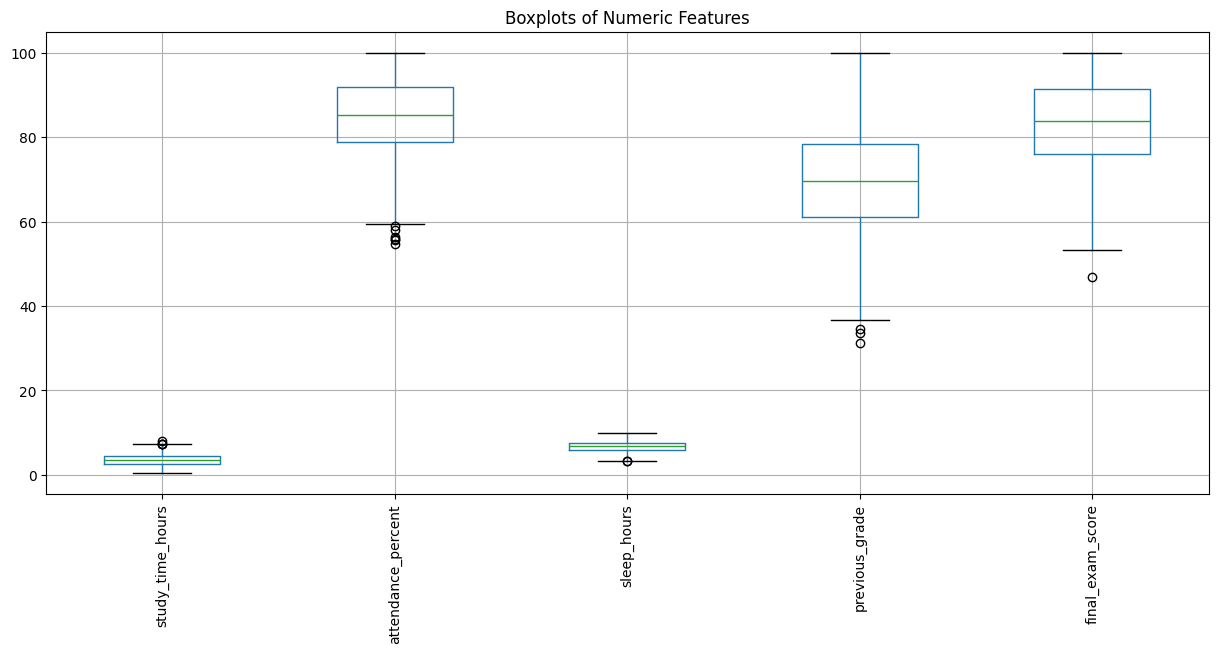

In [13]:
numericdf.boxplot(figsize=(15, 6), rot=90)
plt.title("Boxplots of Numeric Features")
plt.show()

### Incorrect Values

A check on incorrect values was performed on all categorical features to ensure that there weren't duplicate values that were spelt incorrectly or values that plainly didn't make any sense.

In [14]:
categoric = ['object']

catedf = student_performance.select_dtypes(include=categoric)
catedf

,gender,parental_education,internet_access,extracurricular_activities,part_time_job,final_grade
0,Male,Bachelors,Yes,Yes,No,A
1,Female,High School,Yes,Yes,Yes,A
2,Male,Bachelors,Yes,No,Yes,A
3,Male,None,Yes,Yes,No,B
4,Male,Bachelors,Yes,No,Yes,D
...,...,...,...,...,...,...
995,Male,Masters,Yes,Yes,No,C
996,Male,None,No,Yes,No,A
997,Female,High School,Yes,Yes,Yes,C
998,Female,High School,No,No,Yes,B


In [15]:
catedf['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [16]:
catedf['parental_education'].unique()

array(['Bachelors', 'High School', 'None', 'Masters', 'PhD'], dtype=object)

In [17]:
catedf['internet_access'].unique()

array(['Yes', 'No'], dtype=object)

In [18]:
catedf['extracurricular_activities'].unique()

array(['Yes', 'No'], dtype=object)

In [19]:
catedf['part_time_job'].unique()

array(['No', 'Yes'], dtype=object)

In [20]:
catedf['final_grade'].unique()

array(['A', 'B', 'D', 'C', 'F'], dtype=object)

### Encoding the Data

Data needed to be Encoded so that the ML tasks can be run due to the nature that they are usually mathematical equations and as a result need to be formated numerical rather than categorically.

In [21]:
student_performance['gender'] = student_performance['gender'].map({'Female': 1, 'Male': 0})
student_performance['parental_education'] = student_performance['parental_education'].map({'PhD': 4,'Masters': 3,'Bachelors': 2,'High School': 1, 'None': 0})
student_performance['internet_access'] = student_performance['internet_access'].map({'Yes': 1, 'No' : 0})
student_performance['extracurricular_activities'] = student_performance['extracurricular_activities'].map({'Yes': 1, 'No': 0})
student_performance['part_time_job'] = student_performance['part_time_job'].map({'Yes': 1, 'No': 0})

In [22]:
student_performance.head()

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,0,4.0,98.0,6.5,2,1,1,0,76.9,100.0,A
1,1,6.3,100.0,5.7,1,1,1,1,75.5,100.0,A
2,0,4.9,85.3,7.9,2,1,0,1,88.5,97.3,A
3,0,2.6,77.5,8.0,0,1,1,0,85.1,83.8,B
4,0,2.2,89.6,4.6,2,1,0,1,61.8,68.3,D


## UCI Dataset student_data

Nothing needed to be done on this data due to the nature of it being encoded already, if data is missing it can not be found easily if at all.

### Dropping Columns

In [23]:
student_data = student_data.drop('STUDENT ID', axis=1)

In [24]:
student_data.isnull().sum()

1            0
2            0
3            0
4            0
5            0
6            0
7            0
8            0
9            0
10           0
11           0
12           0
13           0
14           0
15           0
16           0
17           0
18           0
19           0
20           0
21           0
22           0
23           0
24           0
25           0
26           0
27           0
28           0
29           0
30           0
COURSE ID    0
GRADE        0
dtype: int64

## Machine Learning Portion

### Kaggle Dataset

In [25]:
target = student_performance['final_grade']
student_performance = student_performance.drop(columns=['final_grade', 'final_exam_score'])
Data_numpy = student_performance.values
X_train_kaggle, X_test_kaggle, y_train_kaggle, y_test_kaggle = train_test_split(Data_numpy, 
                                                    target, 
                                                    test_size=0.3,
                                                    random_state=999)

In [26]:
scaler = StandardScaler()

In [27]:
X_train_kaggle_scaled = scaler.fit_transform(X_train_kaggle)
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

In [28]:
print(X_train_kaggle_scaled.shape)
print(X_test_kaggle_scaled.shape)
print(y_train_kaggle.shape)
print(y_test_kaggle.shape)

(700, 9)
(300, 9)
(700,)
(300,)


### KNN Method

In [29]:
cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

knn_model = KNeighborsClassifier()
knn_params = {
    'n_neighbors': [1, 3, 5, 10, 15, 20], 
    'p': [1, 2, 3, 4, 5],
    'weights': ["uniform", "distance"]}

grid_search = GridSearchCV(
    estimator=knn_model, 
    param_grid=knn_params, 
    scoring="f1_macro", 
    cv=cv_method)

grid_search.fit(X_train_kaggle_scaled, y_train_kaggle)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 10, 15, 20],
                         'p': [1, 2, 3, 4, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [30]:
grid_search.best_params_

{'n_neighbors': 10, 'p': 3, 'weights': 'distance'}

In [31]:
grid_search.score(X_test_kaggle_scaled, y_test_kaggle)

0.30896807965631995

In [32]:
grid_search.best_score_

np.float64(0.3886674808181613)

In [33]:
best_neighbour_kaggle = grid_search.best_estimator_

In [34]:
y_pred_KNN_kaggle = best_neighbour_kaggle.predict(X_test_kaggle_scaled)

In [35]:
y_pred_KNN_kaggle

array(['B', 'C', 'A', 'C', 'A', 'A', 'C', 'B', 'B', 'A', 'B', 'C', 'C',
       'C', 'B', 'C', 'A', 'A', 'C', 'C', 'C', 'B', 'B', 'C', 'C', 'C',
       'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'B', 'C', 'B', 'B', 'B',
       'B', 'A', 'A', 'A', 'C', 'B', 'B', 'C', 'C', 'C', 'A', 'A', 'B',
       'C', 'B', 'B', 'A', 'C', 'A', 'C', 'C', 'B', 'B', 'C', 'A', 'B',
       'A', 'C', 'B', 'A', 'B', 'B', 'B', 'A', 'A', 'C', 'B', 'B', 'C',
       'C', 'C', 'A', 'C', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'C', 'B',
       'C', 'A', 'C', 'B', 'A', 'B', 'A', 'B', 'C', 'B', 'B', 'B', 'B',
       'B', 'A', 'C', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'C', 'B', 'B',
       'B', 'B', 'B', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'B', 'C', 'A',
       'D', 'B', 'A', 'C', 'C', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B',
       'B', 'B', 'A', 'B', 'D', 'B', 'C', 'D', 'A', 'B', 'B', 'B', 'B',
       'B', 'B', 'C', 'A', 'B', 'B', 'B', 'C', 'C', 'C', 'B', 'B', 'B',
       'B', 'C', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'C', 'B', 'C

In [36]:
print(classification_report(y_test_kaggle, y_pred_KNN_kaggle))
print(confusion_matrix(y_test_kaggle, y_pred_KNN_kaggle))

              precision    recall  f1-score   support

           A       0.64      0.46      0.53        94
           B       0.40      0.59      0.48        95
           C       0.45      0.51      0.48        77
           D       0.14      0.03      0.06        29
           F       0.00      0.00      0.00         5

    accuracy                           0.46       300
   macro avg       0.33      0.32      0.31       300
weighted avg       0.46      0.46      0.45       300

[[43 43  8  0  0]
 [19 56 19  1  0]
 [ 5 29 39  4  0]
 [ 0 11 17  1  0]
 [ 0  1  3  1  0]]


C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [37]:
result_KNN_kaggle = permutation_importance(best_neighbour_kaggle, X_test_kaggle_scaled, y_test_kaggle, n_repeats=10, random_state=999, scoring='f1_macro')
feature_importance_KNN_kaggle = pd.DataFrame({
    'feature': student_performance.columns,
    'importance': result_KNN_kaggle.importances_mean
}).sort_values('importance', ascending=False)
print(feature_importance_KNN_kaggle)

                      feature  importance
1            study_time_hours    0.062723
8              previous_grade    0.030298
2          attendance_percent    0.019945
5             internet_access    0.010499
3                 sleep_hours    0.009526
7               part_time_job    0.008290
4          parental_education    0.001700
0                      gender   -0.021001
6  extracurricular_activities   -0.025902


### SVM Method

In [38]:
cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

SVM_model = SVC()
SVM_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']}

grid_search = GridSearchCV(
    estimator=SVM_model, 
    param_grid=SVM_params, 
    scoring="f1_macro", 
    cv=cv_method)

grid_search.fit(X_train_kaggle_scaled, y_train_kaggle)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='f1_macro')

In [39]:
grid_search.best_params_

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

In [40]:
grid_search.score(X_test_kaggle_scaled, y_test_kaggle)

0.4348430539624622

In [41]:
grid_search.best_score_

np.float64(0.4325069471560322)

In [42]:
best_svm_kaggle = grid_search.best_estimator_

In [43]:
y_pred_svm_kaggle = best_svm_kaggle.predict(X_test_kaggle_scaled)

In [44]:
y_pred_svm_kaggle

array(['C', 'C', 'B', 'C', 'B', 'A', 'C', 'B', 'B', 'B', 'B', 'C', 'C',
       'B', 'B', 'C', 'B', 'A', 'C', 'B', 'C', 'B', 'B', 'B', 'B', 'C',
       'D', 'C', 'B', 'B', 'B', 'A', 'A', 'C', 'B', 'C', 'B', 'B', 'A',
       'B', 'B', 'B', 'A', 'B', 'B', 'C', 'C', 'C', 'C', 'A', 'B', 'C',
       'B', 'B', 'B', 'A', 'C', 'A', 'C', 'C', 'A', 'B', 'C', 'A', 'C',
       'B', 'C', 'B', 'A', 'A', 'A', 'D', 'A', 'A', 'C', 'C', 'B', 'C',
       'A', 'B', 'A', 'B', 'A', 'C', 'B', 'B', 'B', 'A', 'C', 'B', 'B',
       'D', 'A', 'B', 'B', 'A', 'B', 'C', 'B', 'C', 'B', 'A', 'B', 'B',
       'B', 'A', 'C', 'B', 'B', 'C', 'B', 'B', 'A', 'A', 'C', 'C', 'B',
       'B', 'B', 'A', 'D', 'C', 'D', 'A', 'B', 'C', 'A', 'B', 'B', 'A',
       'C', 'B', 'A', 'C', 'B', 'D', 'D', 'A', 'C', 'C', 'C', 'D', 'B',
       'B', 'B', 'A', 'B', 'B', 'A', 'C', 'C', 'A', 'A', 'B', 'B', 'B',
       'A', 'B', 'C', 'A', 'A', 'B', 'B', 'C', 'C', 'C', 'B', 'B', 'B',
       'A', 'B', 'A', 'D', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'D

In [45]:
print(classification_report(y_test_kaggle, y_pred_svm_kaggle))
print(confusion_matrix(y_test_kaggle, y_pred_svm_kaggle))

              precision    recall  f1-score   support

           A       0.79      0.62      0.69        94
           B       0.49      0.65      0.56        95
           C       0.49      0.55      0.52        77
           D       0.56      0.31      0.40        29
           F       0.00      0.00      0.00         5

    accuracy                           0.57       300
   macro avg       0.47      0.43      0.43       300
weighted avg       0.59      0.57      0.57       300

[[58 32  4  0  0]
 [13 62 20  0  0]
 [ 2 27 42  6  0]
 [ 0  5 15  9  0]
 [ 0  0  4  1  0]]


C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoisf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [46]:
result_SVM_kaggle = permutation_importance(best_svm_kaggle, X_test_kaggle_scaled, y_test_kaggle, n_repeats=10, random_state=999, scoring='f1_macro')
feature_importance_SVM_kaggle = pd.DataFrame({
    'feature': student_performance.columns,
    'importance': result_SVM_kaggle.importances_mean
}).sort_values('importance', ascending=False)
print(feature_importance_SVM_kaggle)

                      feature  importance
1            study_time_hours    0.144792
8              previous_grade    0.088036
2          attendance_percent    0.040324
7               part_time_job    0.033510
3                 sleep_hours    0.017294
6  extracurricular_activities    0.014705
4          parental_education    0.009361
5             internet_access    0.008934
0                      gender   -0.055673


### UCI Dataset

In [47]:
target = student_data['GRADE']
student_data = student_data.drop(columns=['GRADE'])
Data_numpy = student_data.values
X_train_UCI, X_test_UCI, y_train_UCI, y_test_UCI = train_test_split(Data_numpy, 
                                                    target, 
                                                    test_size=0.3,
                                                    random_state=999)

In [48]:
X_train_UCI_scaled = scaler.fit_transform(X_train_UCI)
X_test_UCI_scaled = scaler.transform(X_test_UCI)

### KNN Method

In [49]:
cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

knn_model = KNeighborsClassifier()
knn_params = {
    'n_neighbors': [1, 3, 5, 10, 15, 20], 
    'p': [1, 2, 3, 4, 5],
    'weights': ["uniform", "distance"]}

grid_search = GridSearchCV(
    estimator=knn_model, 
    param_grid=knn_params, 
    scoring="f1_macro", 
    cv=cv_method)

grid_search.fit(X_train_UCI_scaled, y_train_UCI)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 10, 15, 20],
                         'p': [1, 2, 3, 4, 5],
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [50]:
grid_search.best_params_

{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}

In [51]:
grid_search.score(X_test_UCI_scaled, y_test_UCI)

0.15168650793650795

In [52]:
grid_search.best_score_

np.float64(0.22333656539538893)

In [53]:
best_neighbour_UCI = grid_search.best_estimator_

In [54]:
y_pred_KNN_UCI = best_neighbour_UCI.predict(X_test_UCI_scaled)

In [55]:
y_pred_KNN_UCI

array([3, 1, 1, 3, 0, 1, 1, 1, 3, 3, 1, 1, 1, 3, 1, 1, 1, 0, 5, 1, 1, 1,
       1, 1, 5, 1, 1, 6, 1, 1, 1, 7, 2, 5, 5, 2, 1, 0, 2, 4, 1, 1, 1, 1])

In [56]:
print(classification_report(y_test_UCI, y_pred_KNN_UCI))
print(confusion_matrix(y_test_UCI, y_pred_KNN_UCI))

              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.19      0.50      0.28        10
           2       0.33      0.20      0.25         5
           3       0.40      0.22      0.29         9
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         5

    accuracy                           0.20        44
   macro avg       0.16      0.18      0.15        44
weighted avg       0.18      0.20      0.17        44

[[1 1 0 0 0 0 0 0]
 [1 5 0 2 1 1 0 0]
 [0 3 1 0 0 0 0 1]
 [1 2 1 2 0 3 0 0]
 [0 1 1 0 0 0 0 0]
 [0 6 0 0 0 0 0 0]
 [0 5 0 0 0 0 0 0]
 [0 3 0 1 0 0 1 0]]


In [57]:
result_KNN_UCI = permutation_importance(best_neighbour_UCI, X_test_UCI_scaled, y_test_UCI, n_repeats=10, random_state=999, scoring='f1_macro')
feature_importance_KNN_UCI = pd.DataFrame({
    'feature': student_data.columns,
    'importance': result_KNN_UCI.importances_mean
}).sort_values('importance', ascending=False)
print(feature_importance_KNN_UCI)

      feature  importance
15         16    0.028500
10         11    0.024778
21         22    0.018662
27         28    0.016362
24         25    0.016248
25         26    0.011043
29         30    0.009990
14         15    0.009844
12         13    0.007801
18         19    0.006835
22         23    0.006803
19         20    0.006659
2           3    0.005973
17         18    0.003538
28         29    0.003412
3           4    0.001582
20         21    0.000332
16         17   -0.000149
11         12   -0.002932
5           6   -0.004011
7           8   -0.004083
13         14   -0.004516
1           2   -0.006571
26         27   -0.009757
4           5   -0.011680
0           1   -0.016599
6           7   -0.017616
23         24   -0.020886
9          10   -0.021513
8           9   -0.022298
30  COURSE ID   -0.031531


### SVM Method

In [58]:
cv_method = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=999)

SVM_model = SVC()
SVM_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']}

grid_search = GridSearchCV(
    estimator=SVM_model, 
    param_grid=SVM_params, 
    scoring="f1_macro", 
    cv=cv_method)

grid_search.fit(X_train_UCI_scaled, y_train_UCI)

GridSearchCV(cv=KFold(n_splits=5, random_state=999, shuffle=True),
             estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='f1_macro')

In [59]:
grid_search.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'linear'}

In [60]:
grid_search.score(X_test_UCI_scaled, y_test_UCI)

0.2576850233100233

In [61]:
grid_search.best_score_

np.float64(0.1803907203907204)

In [62]:
best_svm_UCI = grid_search.best_estimator_

In [63]:
y_pred_svm_UCI = best_svm_UCI.predict(X_test_UCI_scaled)

In [64]:
y_pred_svm_UCI

array([3, 2, 1, 1, 0, 1, 5, 5, 0, 3, 3, 7, 6, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       1, 4, 5, 7, 1, 4, 0, 7, 1, 2, 3, 3, 5, 1, 2, 0, 2, 5, 1, 1, 3, 3])

In [65]:
result_SVM_UCI = permutation_importance(best_svm_UCI, X_test_UCI_scaled, y_test_UCI, n_repeats=10, random_state=999, scoring='f1_macro')
feature_importance_SVM_UCI = pd.DataFrame({
    'feature': student_data.columns,
    'importance': result_SVM_UCI.importances_mean
}).sort_values('importance', ascending=False)
print(feature_importance_SVM_UCI)

      feature  importance
24         25    0.072192
30  COURSE ID    0.061514
28         29    0.058682
1           2    0.058392
12         13    0.054614
4           5    0.045400
16         17    0.043612
11         12    0.041212
5           6    0.036635
21         22    0.032535
10         11    0.031678
15         16    0.030239
27         28    0.027673
17         18    0.027503
14         15    0.025551
20         21    0.023146
13         14    0.022170
7           8    0.021419
3           4    0.021087
0           1    0.020957
26         27    0.011924
2           3    0.011146
18         19    0.007305
29         30    0.006086
25         26    0.003363
19         20    0.001016
23         24   -0.001722
8           9   -0.004170
22         23   -0.004925
9          10   -0.012438
6           7   -0.018387


In [66]:
print(classification_report(y_test_UCI, y_pred_svm_UCI))
print(confusion_matrix(y_test_UCI, y_pred_svm_UCI))

              precision    recall  f1-score   support

           0       0.25      0.50      0.33         2
           1       0.25      0.40      0.31        10
           2       0.33      0.40      0.36         5
           3       0.43      0.33      0.38         9
           4       0.00      0.00      0.00         2
           5       0.20      0.17      0.18         6
           6       0.00      0.00      0.00         5
           7       0.67      0.40      0.50         5

    accuracy                           0.30        44
   macro avg       0.27      0.28      0.26        44
weighted avg       0.30      0.30      0.28        44

[[1 0 0 1 0 0 0 0]
 [2 4 1 0 0 2 1 0]
 [0 2 2 1 0 0 0 0]
 [1 2 1 3 1 1 0 0]
 [0 1 1 0 0 0 0 0]
 [0 3 1 1 0 1 0 0]
 [0 2 0 1 0 1 0 1]
 [0 2 0 0 1 0 0 2]]
